<a href="https://colab.research.google.com/github/Darshan-12345/Deep-Learning-/blob/main/Assignments/Assignment-07/DL_ASS_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0

 Training Model: AlexNet
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5675 - loss: 4.6742 - val_accuracy: 0.5775 - val_loss: 1.6591
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8269 - loss: 0.5972 - val_accuracy: 0.1800 - val_loss: 7.0336
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8794 - loss: 0.4047 - val_accuracy: 0.1800 - val_loss: 13.7016
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9025 - loss: 0.3386 - val_accuracy: 0.1800 - val_loss: 18.6304
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9019 - loss: 0.3074 - val_accuracy: 0.1800 - val_loss: 21.5683

 Training Model: VGG16
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.3288 - loss: 1.9268 - val_accuracy: 0.6900 - val_loss: 1.3160
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5894 - loss: 1.2890 - val_accuracy: 0.7875 - val_loss: 0.9563
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0

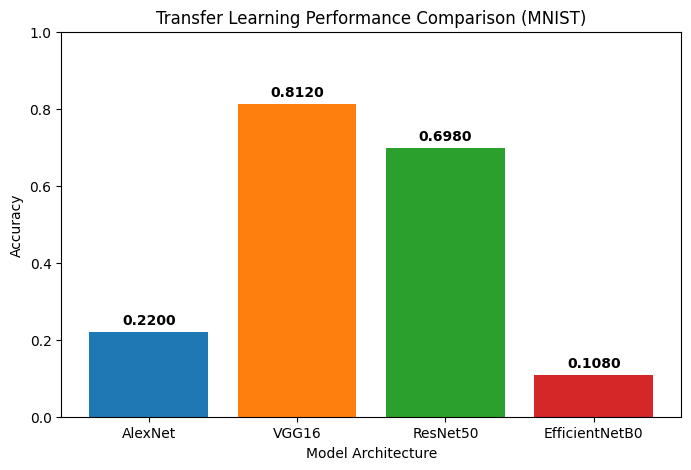

In [ ]:
# ==========================================
# 1. IMPORT LIBRARIES & DEPENDENCIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow version:", tf.__version__)

# ==========================================
# 2. LOAD & PREPROCESS DATASET (MNIST)
# ==========================================
# Load MNIST dataset (10 digit classes)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Subset for fast execution (2000 train, 500 test)
train_size, test_size = 2000, 500
X_train, y_train = X_train[:train_size], y_train[:train_size]
X_test, y_test = X_test[:test_size], y_test[:test_size]

# Convert grayscale to 3 channels (28, 28, 3) and normalize
X_train = np.repeat(X_train[..., np.newaxis], 3, axis=-1) / 255.0
X_test = np.repeat(X_test[..., np.newaxis], 3, axis=-1) / 255.0

# Resize images from 28x28 to 32x32 to meet pre-trained model input constraints
X_train = tf.image.resize(X_train, (32, 32)).numpy()
X_test = tf.image.resize(X_test, (32, 32)).numpy()

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

input_shape = (32, 32, 3)

# ==========================================
# 3. BUILD MODEL ARCHITECTURES
# ==========================================

# --- A. AlexNet Architecture ---
def build_alexnet(input_shape=input_shape, num_classes=10):
    model = Sequential([
        Input(shape=input_shape),
        tf.keras.layers.Conv2D(96, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2, 2)),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name="AlexNet")
    return model

# --- B. Pre-trained VGG16 ---
def build_vgg16(input_shape=input_shape, num_classes=10):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze pre-trained weights

    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=output, name="VGG16")

# --- C. Pre-trained ResNet50 ---
def build_resnet50(input_shape=input_shape, num_classes=10):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze pre-trained weights

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=output, name="ResNet50")

# --- D. Pre-trained EfficientNetB0 ---
def build_efficientnet(input_shape=input_shape, num_classes=10):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze pre-trained weights

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base_model.input, outputs=output, name="EfficientNetB0")

# ==========================================
# 4. MODEL TRAINING & EVALUATION LOOP
# ==========================================
models = {
    "AlexNet": build_alexnet(),
    "VGG16": build_vgg16(),
    "ResNet50": build_resnet50(),
    "EfficientNetB0": build_efficientnet()
}

results = []

for model_name, model in models.items():
    print("\n" + "=" * 50)
    print(f" Training Model: {model_name}")
    print("=" * 50)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Fast training with 5 epochs
    model.fit(
        X_train, y_train_cat,
        validation_split=0.2,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    # Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Compute Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# ==========================================
# 5. PERFORMANCE COMPARISON TABLE & PLOT
# ==========================================
results_df = pd.DataFrame(results)

print("\n" + "=" * 50)
print(" PERFORMANCE COMPARISON SUMMARY")
print("=" * 50)
print(results_df.to_string(index=False))

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlabel("Model Architecture")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Performance Comparison (MNIST)")
plt.ylim(0, 1.0)
for index, value in enumerate(results_df["Accuracy"]):
    plt.text(index, value + 0.02, f"{value:.4f}", ha='center', fontweight='bold')
plt.show()